# Notebook 33 — Plating-risk localization map

## Goal

Localize where and under which internal-state conditions the negative-electrode plating-margin risk becomes most severe under DC–AC excitation.

Notebook 33 does **not** search for the fastest DC–AC protocol. It continues the Day30–Day32 mainline and asks:

> Under an admissible-fast-protocol framing, where does the minimum negative-electrode margin occur, and which state variables explain that risk?

## Scientific context

The current DC–AC project framing is no longer:

```text
Find the fastest frequency/amplitude combination.
```

It is now:

```text
Find an admissible DC–AC protocol under timing, geometry-residual, microstate, plating-margin, and future thermal/aging constraints.
```

Previous results:

- Notebook 30: DC–AC generates equal-Q microstate differences, but raw timing gain is geometry-dominated.
- Notebook 31: Chen2020 / DFN shows an amplitude-dependent negative-electrode hard-margin boundary at fixed `1.5τ_set`.
- Notebook 32: timing geometry dominance transfers across Chen2020 / Ecker2015 / ORegan2022, but plating-margin admissibility is strongly parameter-set dependent.

Notebook 33 moves from **gain–margin classification** to **risk-trigger localization**.

## Day33A — Variable lineage and registry freeze

Day33A does not run protocols. It freezes the variable logic for Day33B and Day33C by combining:

```text
previous notebook lineage
→ current notebook availability verification
→ Day33 variable registry
```

Day33A outputs:

- `data/day33_variable_inventory.csv`
- `data/day33_prior_notebook_variable_lineage.csv`
- `data/day33_prior_plating_margin_file_inventory.csv`
- `data/day33_variable_registry.csv`

## Day33B — Plating-risk localization at fixed 1.5τ_set

Day33B localizes the risk trigger at the Day30–Day32 mainline frequency.

Minimum Chen2020 / DFN protocol set:

- DC `0.3C`
- DC–AC `0.3C + 0.7C`: stress case
- DC–AC `0.3C + 0.38C`: near hard-margin boundary
- DC–AC `0.3C + 0.3C`: intermediate reference

Mainline frequency mode:

```text
set_rebased
f_set = 1 / (2π · tau_factor · τ_ref,set)
```

For Chen2020 Day33B:

```text
τ_ref,set = Day17 tau2_biexp = 36.316532 s
tau_factor = 1.5
f_main ≈ 0.002922 Hz
```

Day33B asks whether the minimum `U_NE` occurs near high Q/SOC, near the 4.2 V voltage boundary, at the AC charge-current peak, or under specific transport / surface-state conditions.

## Day33C — Frequency sensitivity of risk localization

Day33C checks whether the Day33B risk-trigger structure is stable across representative normalized frequencies.

It does not perform a full frequency–amplitude optimization. It uses the near-boundary amplitude from Day31/Day32:

```text
DC = 0.3C
AC = 0.38C
```

and scans representative set-rebased frequencies:

```text
0.5τ_set
1.5τ_set
3.0τ_set
5.0τ_set
```

The purpose is to test whether the risk localization remains:

```text
high-Q / voltage-boundary-adjacent / charge-current-peak coupled
```

or whether it changes with forcing timescale, e.g. becomes more transport-gradient dominated or more nonlocal at longer periods.

Day33C outputs should include:

- `min_U_NE_mV`
- `Q_at_min_U_NE`
- `phase_norm_at_min_U_NE`
- `I_charge_at_min_U_NE`
- `distance_to_4.2V`
- `c_e_range_at_min_U_NE`
- `negative surface stoichiometry / heterogeneity at min_U_NE`
- `trigger_label`
- `risk_mechanism_class`

## Frequency boundary

MJ1 fixed-label frequencies are not part of the Day33 mainline. They may only be used later as a separate fixed-frequency transfer control.

Day33 mainline frequency calculations are parameter-set-specific:

```text
f_set = 1 / (2π · tau_factor · τ_ref,set)
```

For the current Chen2020 / DFN Day33 work, `τ_ref,set` follows the Day30–Day32 mainline value from the Day17 tau2_biexp descriptor matrix.

## Interpretation boundary

- `Negative electrode surface potential difference [V]` is the primary plating-margin proxy.
- The primary proxy is reduced by spatial minimum over the negative electrode.
- Negative-electrode OCP is not a plating-margin proxy.
- Overpotential, electrolyte concentration, and stoichiometry variables are explanatory variables.
- `risk_flag` means the selected negative-electrode potential proxy crosses the audit threshold; it is not confirmed lithium plating.
- The 50 mV threshold is an audit buffer, not a universal physical constant.
- Notebook 33 is still isothermal; thermal admissibility is deferred.
- Notebook 33 does not prove DC–AC is plating-free or that non-geometric acceleration exists.


In [5]:
# Cell 1 — Imports, paths, and Day33 metadata（导入库、路径与Day33元数据）

from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"
NOTEBOOK_DIR = REPO / "notebooks"
DOCS_TABLE_DIR = DOCS_DIR / "tables"
DOCS_FIG_DIR = DOCS_DIR / "figures"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR, DOCS_TABLE_DIR, DOCS_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
FREQUENCY_MODE = "set_rebased"
TAU_FACTOR_MAIN = 1.5
TAU_REF_SOURCE = "Day17 tau2_biexp descriptor matrix"

# Day30-Day32 mainline Chen2020 tau_ref.
TAU_REF_SET_S = 36.316532231592305
F_MAIN_HZ = 1.0 / (2.0 * np.pi * TAU_FACTOR_MAIN * TAU_REF_SET_S)

DAY33_METADATA = {
    "notebook": "33_plating_risk_localization_map.ipynb",
    "primary_parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_main": TAU_FACTOR_MAIN,
    "tau_ref_source": TAU_REF_SOURCE,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_main_Hz": F_MAIN_HZ,
    "lineage_note": "Day33 continues the Day30-Day32 set-rebased mainline. MJ1 fixed-label frequencies are excluded from the mainline.",
}

metadata_path = DATA_DIR / "day33_metadata.json"
metadata_path.write_text(json.dumps(DAY33_METADATA, indent=2), encoding="utf-8")

print("[OK] repo root:", REPO)
print("[OK] data dir:", DATA_DIR)
print("[OK] figures dir:", FIG_DIR)
print("[OK] docs dir:", DOCS_DIR)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] frequency mode:", FREQUENCY_MODE)
print("[OK] tau_ref_set_s:", TAU_REF_SET_S)
print("[OK] f_main_Hz:", F_MAIN_HZ)
print("[OK] saved metadata:", metadata_path)

[OK] repo root: /Users/louislu/pybamm-dcac-superimposed
[OK] data dir: /Users/louislu/pybamm-dcac-superimposed/data
[OK] figures dir: /Users/louislu/pybamm-dcac-superimposed/figures
[OK] docs dir: /Users/louislu/pybamm-dcac-superimposed/docs
[OK] pybamm version: 26.3.1
[OK] frequency mode: set_rebased
[OK] tau_ref_set_s: 36.316532231592305
[OK] f_main_Hz: 0.002921625190367048
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day33_metadata.json


In [6]:
# Cell 2 — Current-run variable inventory（当前模型变量清单）

model = pybamm.lithium_ion.DFN({"thermal": "isothermal"})
parameter_values = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
sim = pybamm.Simulation(model, parameter_values=parameter_values)
sim.build()

all_keys = sorted(list(sim.built_model.variables.keys()))

KEYWORD_GROUPS = {
    "plating_margin": [
        "surface potential difference",
        "negative electrode potential",
        "negative electrode surface potential",
        "electrolyte potential",
    ],
    "ocp_reference": [
        "open-circuit potential",
        "equilibrium open-circuit potential",
    ],
    "kinetic_state": [
        "reaction overpotential",
        "interfacial current density",
    ],
    "transport_state": [
        "electrolyte concentration",
        "electrolyte potential",
    ],
    "surface_state": [
        "surface stoichiometry",
        "particle surface concentration",
        "negative particle stoichiometry",
    ],
    "plating_submodel_variables": [
        "lithium plating",
        "plating",
    ],
}

inventory_rows = []

for group, terms in KEYWORD_GROUPS.items():
    for term in terms:
        matches = [k for k in all_keys if term.lower() in k.lower()]
        for key in matches:
            inventory_rows.append({
                "keyword_group": group,
                "search_term": term,
                "variable_key": key,
            })

variable_inventory_df = (
    pd.DataFrame(inventory_rows)
    .drop_duplicates()
    .sort_values(["keyword_group", "search_term", "variable_key"])
    .reset_index(drop=True)
)

out = DATA_DIR / "day33_variable_inventory.csv"
variable_inventory_df.to_csv(out, index=False)

print("[OK] saved variable inventory:", out)
print("[INFO] matched variables:", len(variable_inventory_df))
display(variable_inventory_df.head(250))


[OK] saved variable inventory: /Users/louislu/pybamm-dcac-superimposed/data/day33_variable_inventory.csv
[INFO] matched variables: 204


,keyword_group,search_term,variable_key
0,kinetic_state,interfacial current density,Interfacial current density [A.m-2]
1,kinetic_state,interfacial current density,Negative electrode SEI interfacial current density [A.m-2]
2,kinetic_state,interfacial current density,Negative electrode SEI on cracks interfacial current density [A.m-2]
3,kinetic_state,interfacial current density,Negative electrode SEI on cracks volumetric interfacial current density [A.m-3]
4,kinetic_state,interfacial current density,Negative electrode SEI volumetric interfacial current density [A.m-3]
...,...,...,...
199,transport_state,electrolyte potential,Separator electrolyte potential [V]
200,transport_state,electrolyte potential,X-averaged electrolyte potential [V]
201,transport_state,electrolyte potential,X-averaged negative electrolyte potential [V]
202,transport_state,electrolyte potential,X-averaged positive electrolyte potential [V]


In [7]:
# Cell 2.2 — Search prior notebooks for variable lineage（搜索历史notebook中的变量谱系）

SEARCH_PATTERNS = [
    "Negative electrode surface potential difference [V]",
    "Negative electrode surface potential difference at separator interface [V]",
    "X-averaged negative electrode surface potential difference [V]",
    "Negative electrode reaction overpotential [V]",
    "X-averaged negative electrode reaction overpotential [V]",
    "Electrolyte concentration [mol.m-3]",
    "X-averaged electrolyte concentration [mol.m-3]",
    "Average negative particle surface stoichiometry",
    "X-averaged negative particle surface stoichiometry",
    "Maximum negative particle surface stoichiometry",
    "Minimum negative particle surface stoichiometry",
    "Negative electrode open-circuit potential [V]",
    "X-averaged negative electrode open-circuit potential [V]",
    "Negative electrode equilibrium open-circuit potential [V]",
]

PRIOR_NOTEBOOK_PREFIXES = ("30_", "31_", "32_")
lineage_rows = []

for nb_path in sorted(NOTEBOOK_DIR.glob("*.ipynb")):
    if not nb_path.name.startswith(PRIOR_NOTEBOOK_PREFIXES):
        continue

    try:
        nb_json = json.loads(nb_path.read_text(encoding="utf-8"))
    except Exception as e:
        lineage_rows.append({
            "notebook": nb_path.name,
            "cell_index": None,
            "matched_pattern": None,
            "line_excerpt": None,
            "status": "read_failed",
            "error": repr(e),
        })
        continue

    for idx, cell in enumerate(nb_json.get("cells", [])):
        src = "".join(cell.get("source", []))
        for pattern in SEARCH_PATTERNS:
            if pattern in src:
                lines = src.splitlines()
                match_lines = [ln.strip() for ln in lines if pattern in ln]
                excerpt = match_lines[0] if match_lines else ""
                lineage_rows.append({
                    "notebook": nb_path.name,
                    "cell_index": idx,
                    "cell_type": cell.get("cell_type", ""),
                    "matched_pattern": pattern,
                    "line_excerpt": excerpt[:300],
                    "status": "matched",
                    "error": "",
                })

prior_lineage_df = pd.DataFrame(lineage_rows)

if prior_lineage_df.empty:
    prior_lineage_df = pd.DataFrame(columns=[
        "notebook", "cell_index", "cell_type", "matched_pattern",
        "line_excerpt", "status", "error"
    ])

out = DATA_DIR / "day33_prior_notebook_variable_lineage.csv"
prior_lineage_df.to_csv(out, index=False)

print("[OK] saved prior notebook variable lineage:", out)
print("[INFO] matches:", len(prior_lineage_df))
display(prior_lineage_df)

[OK] saved prior notebook variable lineage: /Users/louislu/pybamm-dcac-superimposed/data/day33_prior_notebook_variable_lineage.csv
[INFO] matches: 17


,notebook,cell_index,cell_type,matched_pattern,line_excerpt,status,error
0,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,Negative electrode reaction overpotential [V],"""Negative electrode reaction overpotential [V]"",",matched,
1,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,X-averaged negative electrode reaction overpotential [V],"""X-averaged negative electrode reaction overpotential [V]"",",matched,
2,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,Electrolyte concentration [mol.m-3],"""Electrolyte concentration [mol.m-3]"",",matched,
3,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,X-averaged electrolyte concentration [mol.m-3],"""X-averaged electrolyte concentration [mol.m-3]"",",matched,
4,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,Average negative particle surface stoichiometry,"""Average negative particle surface stoichiometry"",",matched,
5,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,X-averaged negative particle surface stoichiometry,"""X-averaged negative particle surface stoichiometry"",",matched,
6,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,Maximum negative particle surface stoichiometry,"""Maximum negative particle surface stoichiometry"",",matched,
7,30_microstate_dfn_spme_spm_dcac_audit.ipynb,15,code,Minimum negative particle surface stoichiometry,"""Minimum negative particle surface stoichiometry"",",matched,
8,31_negative_electrode_plating_margin_audit.ipynb,7,code,Negative electrode surface potential difference [V],"NE_SURFACE_KEY = ""Negative electrode surface potential difference [V]""",matched,
9,31_negative_electrode_plating_margin_audit.ipynb,7,code,Negative electrode surface potential difference at separator interface [V],"NE_SEPARATOR_KEY = ""Negative electrode surface potential difference at separator interface [V]""",matched,


In [8]:
# Cell 2.3 — Locate prior plating-margin output files（定位历史析锂余量输出文件）

EXPECTED_PRIOR_FILES = [
    "day31_protocol_plating_margin_summary_smoke.csv",
    "day31_gain_margin_admissibility_ledger_smoke.csv",
    "day31_amplitude_admissibility_ledger_1p5tau.csv",
    "day31_fine_amplitude_admissibility_ledger_1p5tau.csv",
    "day31_amplitude_boundary_synthesis_1p5tau.csv",
    "day32_cross_parameter_protocol_margin_summary.csv",
    "day32_cross_parameter_hard_margin_boundary_summary.csv",
    "day32_cross_parameter_gain_margin_transfer_summary.csv",
    "day32_cross_parameter_transfer_verdict.csv",
]

file_rows = []

for name in EXPECTED_PRIOR_FILES:
    path = DATA_DIR / name
    exists = path.exists()

    n_rows = np.nan
    columns = ""

    if exists:
        try:
            df = pd.read_csv(path)
            n_rows = len(df)
            columns = "; ".join(df.columns.tolist())
        except Exception as e:
            columns = f"READ_ERROR: {repr(e)}"

    file_rows.append({
        "file": name,
        "path": str(path),
        "exists": exists,
        "n_rows": n_rows,
        "columns": columns,
    })

prior_file_inventory_df = pd.DataFrame(file_rows)

out = DATA_DIR / "day33_prior_plating_margin_file_inventory.csv"
prior_file_inventory_df.to_csv(out, index=False)

print("[OK] saved prior plating-margin file inventory:", out)
display(prior_file_inventory_df)


[OK] saved prior plating-margin file inventory: /Users/louislu/pybamm-dcac-superimposed/data/day33_prior_plating_margin_file_inventory.csv


,file,path,exists,n_rows,columns
0,day31_protocol_plating_margin_summary_smoke.csv,/Users/louislu/pybamm-dcac-superimposed/data/day31_protocol_plating_margin_summary_smoke.csv,True,5,parameter_set; model_type; condition; protocol_type; dc_c; ac_c; tau_factor_set; f_Hz; period_s; t_end_s; t_end_min; Q_end_Ah; V_end_V; ...
1,day31_gain_margin_admissibility_ledger_smoke.csv,/Users/louislu/pybamm-dcac-superimposed/data/day31_gain_margin_admissibility_ledger_smoke.csv,True,4,condition; tau_factor_set; delta_t_raw_mean_s; U_NE_min_DCAC_min_mV; U_NE_min_DCAC_mean_mV; delta_U_NE_min_mean_mV; delta_U_NE_min_min_m...
2,day31_amplitude_admissibility_ledger_1p5tau.csv,/Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_admissibility_ledger_1p5tau.csv,True,6,condition; dc_c; ac_c; peak_c; tau_factor_set; delta_t_raw_mean_s; U_NE_min_DCAC_min_mV; U_NE_min_DCAC_mean_mV; delta_U_NE_min_mean_mV; ...
3,day31_fine_amplitude_admissibility_ledger_1p5tau.csv,/Users/louislu/pybamm-dcac-superimposed/data/day31_fine_amplitude_admissibility_ledger_1p5tau.csv,True,6,condition; dc_c; ac_c; peak_c; tau_factor_set; delta_t_raw_mean_s; U_NE_min_DCAC_min_mV; U_NE_min_DCAC_mean_mV; delta_U_NE_min_mean_mV; ...
4,day31_amplitude_boundary_synthesis_1p5tau.csv,/Users/louislu/pybamm-dcac-superimposed/data/day31_amplitude_boundary_synthesis_1p5tau.csv,True,2,audit_layer; frequency; estimated_AC_C_at_0mV; estimated_peak_C_at_0mV; interpretation
5,day32_cross_parameter_protocol_margin_summary.csv,/Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_protocol_margin_summary.csv,True,27,parameter_set; chem_tag; model_type; condition; protocol_type; dc_c; ac_c; peak_c; tau_factor_set; tau_ref_set_s; f_Hz; period_s; t_end_...
6,day32_cross_parameter_hard_margin_boundary_summary.csv,/Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_hard_margin_boundary_summary.csv,True,3,parameter_set; dc_min_U_NE_mV; dc_margin_class; min_scanned_AC_C; max_scanned_AC_C; estimated_AC_C_at_0mV; estimated_peak_C_at_0mV; boun...
7,day32_cross_parameter_gain_margin_transfer_summary.csv,/Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_gain_margin_transfer_summary.csv,True,24,parameter_set; condition; ac_c; peak_c; tau_factor_set; delta_t_raw_mean_s; delta_t_raw_min_s; delta_t_raw_max_s; delta_t_geom_mean_s; d...
8,day32_cross_parameter_transfer_verdict.csv,/Users/louislu/pybamm-dcac-superimposed/data/day32_cross_parameter_transfer_verdict.csv,True,3,parameter_set; dc_min_U_NE_mV; dc_margin_class; n_scanned_DCAC; n_safe_margin; n_near_boundary; n_risk_flag; estimated_AC_C_at_0mV; esti...


In [9]:
# Cell 2.4 — Freeze Day33 variable registry（冻结Day33变量注册表）

current_keys = set(all_keys)

registry_specs = [
    {
        "role": "primary_plating_margin_proxy",
        "variable_key": "Negative electrode surface potential difference [V]",
        "reducer": "spatial_min",
        "interpretation": "Primary U_NE vs Li/Li+ proxy; use spatial minimum over negative electrode.",
        "primary_allowed": True,
        "boundary_note": "Thermodynamic proxy only; risk_flag is not confirmed lithium plating.",
    },
    {
        "role": "local_plating_margin_proxy",
        "variable_key": "Negative electrode surface potential difference at separator interface [V]",
        "reducer": "direct_timeseries",
        "interpretation": "Separator-interface local margin check; auxiliary to spatial minimum.",
        "primary_allowed": False,
        "boundary_note": "Useful local diagnostic, but primary metric remains spatial minimum if available.",
    },
    {
        "role": "xavg_margin_secondary",
        "variable_key": "X-averaged negative electrode surface potential difference [V]",
        "reducer": "direct_timeseries",
        "interpretation": "Average negative-electrode margin; secondary only, not a local-risk substitute.",
        "primary_allowed": False,
        "boundary_note": "X-averaged value can hide local plating-margin risk.",
    },
    {
        "role": "ocp_reference",
        "variable_key": "Negative electrode open-circuit potential [V]",
        "reducer": "mean_or_direct",
        "interpretation": "Equilibrium reference only.",
        "primary_allowed": False,
        "boundary_note": "OCP is not plating-margin proxy because it excludes electrolyte potential and kinetic polarization.",
    },
    {
        "role": "forbidden_as_primary",
        "variable_key": "Negative electrode open-circuit potential [V]",
        "reducer": "not_applicable",
        "interpretation": "Explicitly forbidden as primary plating-risk metric.",
        "primary_allowed": False,
        "boundary_note": "Negative electrode OCP is not U_NE vs Li/Li+ under load.",
    },
    {
        "role": "kinetic_state",
        "variable_key": "X-averaged negative electrode reaction overpotential [V]",
        "reducer": "direct_timeseries",
        "interpretation": "Negative-electrode kinetic polarization state.",
        "primary_allowed": False,
        "boundary_note": "Explanatory variable; not a standalone plating-margin criterion.",
    },
    {
        "role": "transport_state",
        "variable_key": "Electrolyte concentration [mol.m-3]",
        "reducer": "range_min_max",
        "interpretation": "Electrolyte transport state and concentration-gradient proxy.",
        "primary_allowed": False,
        "boundary_note": "Explanatory variable for margin loss and polarization.",
    },
    {
        "role": "surface_state",
        "variable_key": "X-averaged negative particle surface stoichiometry",
        "reducer": "direct_timeseries",
        "interpretation": "Average negative surface lithiation state.",
        "primary_allowed": False,
        "boundary_note": "Explanatory state variable; high surface lithiation may reduce margin.",
    },
    {
        "role": "surface_heterogeneity_state",
        "variable_key": "Maximum negative particle surface stoichiometry",
        "reducer": "direct_timeseries",
        "interpretation": "Upper bound of negative surface stoichiometry; local saturation proxy.",
        "primary_allowed": False,
        "boundary_note": "Explanatory variable for surface saturation risk.",
    },
    {
        "role": "surface_heterogeneity_state",
        "variable_key": "Minimum negative particle surface stoichiometry",
        "reducer": "direct_timeseries",
        "interpretation": "Lower bound of negative surface stoichiometry; enables surface range.",
        "primary_allowed": False,
        "boundary_note": "Used with maximum surface stoichiometry to estimate heterogeneity.",
    },
]

registry_rows = []

for spec in registry_specs:
    key = spec["variable_key"]
    registry_rows.append({
        **spec,
        "available_in_current_model": key in current_keys,
        "parameter_set": PRIMARY_PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "frequency_mode": FREQUENCY_MODE,
        "tau_factor_main": TAU_FACTOR_MAIN,
        "tau_ref_set_s": TAU_REF_SET_S,
        "tau_ref_source": TAU_REF_SOURCE,
    })

variable_registry_df = pd.DataFrame(registry_rows)

out = DATA_DIR / "day33_variable_registry.csv"
variable_registry_df.to_csv(out, index=False)

print("[OK] saved Day33 variable registry:", out)
display(variable_registry_df)

missing_required = variable_registry_df[
    (variable_registry_df["role"] == "primary_plating_margin_proxy")
    & (~variable_registry_df["available_in_current_model"])
]

if len(missing_required) > 0:
    raise RuntimeError("Primary plating-margin proxy is missing in current model.")
else:
    print("[OK] primary plating-margin proxy available.")

[OK] saved Day33 variable registry: /Users/louislu/pybamm-dcac-superimposed/data/day33_variable_registry.csv


,role,variable_key,reducer,interpretation,primary_allowed,boundary_note,available_in_current_model,parameter_set,model_type,frequency_mode,tau_factor_main,tau_ref_set_s,tau_ref_source
0,primary_plating_margin_proxy,Negative electrode surface potential difference [V],spatial_min,Primary U_NE vs Li/Li+ proxy; use spatial minimum over negative electrode.,True,Thermodynamic proxy only; risk_flag is not confirmed lithium plating.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
1,local_plating_margin_proxy,Negative electrode surface potential difference at separator interface [V],direct_timeseries,Separator-interface local margin check; auxiliary to spatial minimum.,False,"Useful local diagnostic, but primary metric remains spatial minimum if available.",True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
2,xavg_margin_secondary,X-averaged negative electrode surface potential difference [V],direct_timeseries,"Average negative-electrode margin; secondary only, not a local-risk substitute.",False,X-averaged value can hide local plating-margin risk.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
3,ocp_reference,Negative electrode open-circuit potential [V],mean_or_direct,Equilibrium reference only.,False,OCP is not plating-margin proxy because it excludes electrolyte potential and kinetic polarization.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
4,forbidden_as_primary,Negative electrode open-circuit potential [V],not_applicable,Explicitly forbidden as primary plating-risk metric.,False,Negative electrode OCP is not U_NE vs Li/Li+ under load.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
5,kinetic_state,X-averaged negative electrode reaction overpotential [V],direct_timeseries,Negative-electrode kinetic polarization state.,False,Explanatory variable; not a standalone plating-margin criterion.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
6,transport_state,Electrolyte concentration [mol.m-3],range_min_max,Electrolyte transport state and concentration-gradient proxy.,False,Explanatory variable for margin loss and polarization.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
7,surface_state,X-averaged negative particle surface stoichiometry,direct_timeseries,Average negative surface lithiation state.,False,Explanatory state variable; high surface lithiation may reduce margin.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
8,surface_heterogeneity_state,Maximum negative particle surface stoichiometry,direct_timeseries,Upper bound of negative surface stoichiometry; local saturation proxy.,False,Explanatory variable for surface saturation risk.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix
9,surface_heterogeneity_state,Minimum negative particle surface stoichiometry,direct_timeseries,Lower bound of negative surface stoichiometry; enables surface range.,False,Used with maximum surface stoichiometry to estimate heterogeneity.,True,Chen2020,DFN,set_rebased,1.5,36.316532,Day17 tau2_biexp descriptor matrix


[OK] primary plating-margin proxy available.


## Day33B — Plating-risk localization map

Day33A froze the variable logic:

- primary plating-margin proxy: `Negative electrode surface potential difference [V]`, reduced by spatial minimum;
- OCP is only an equilibrium reference and must not be used as the primary plating-margin criterion;
- overpotential, electrolyte concentration, and surface stoichiometry are explanatory state variables.

Day33B now localizes where the minimum negative-electrode margin occurs.

Minimum protocol set:

- `DC 0.3C`
- `DC–AC 0.3C + 0.7C`: stress case
- `DC–AC 0.3C + 0.38C`: near hard-margin boundary from Day31
- `DC–AC 0.3C + 0.3C`: intermediate reference

Main frequency:

```text
set-rebased 1.5τ_set
τ_ref,set = 36.316532 s
f_main ≈ 0.002922 Hz
```

The goal is not to find a faster protocol. The goal is to identify the Q/SOC, AC phase, current, voltage-boundary distance, electrolyte state, surface stoichiometry, and overpotential state at which plating-margin risk is maximal.

In [10]:
# Cell 3 — Day33B protocol table（Day33B协议表）

DC_C = 0.3
DAY33B_AC_CASES = [
    {"label": "AC0p7_stress", "ac_c": 0.70, "role": "stress_case"},
    {"label": "AC0p38_boundary", "ac_c": 0.38, "role": "near_hard_margin_boundary"},
    {"label": "AC0p3_intermediate", "ac_c": 0.30, "role": "intermediate_reference"},
]

protocol_rows = []

protocol_rows.append({
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "condition": "Chen2020_DFN_Day33B_DC03",
    "protocol_type": "DC",
    "case_role": "dc_reference",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "peak_c": DC_C,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_set": np.nan,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
})

for spec in DAY33B_AC_CASES:
    ac_c = spec["ac_c"]
    protocol_rows.append({
        "parameter_set": PRIMARY_PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "condition": f"Chen2020_DFN_Day33B_DC03_{spec['label']}",
        "protocol_type": "DCAC",
        "case_role": spec["role"],
        "dc_c": DC_C,
        "ac_c": ac_c,
        "peak_c": DC_C + ac_c,
        "frequency_mode": FREQUENCY_MODE,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "tau_ref_set_s": TAU_REF_SET_S,
        "f_Hz": F_MAIN_HZ,
        "period_s": 1.0 / F_MAIN_HZ,
        "omega_tau_set": 1.0 / TAU_FACTOR_MAIN,
    })

day33b_protocol_df = pd.DataFrame(protocol_rows)

out = DATA_DIR / "day33b_protocol_table.csv"
day33b_protocol_df.to_csv(out, index=False)

print("[OK] saved Day33B protocol table:", out)
display(day33b_protocol_df)

[OK] saved Day33B protocol table: /Users/louislu/pybamm-dcac-superimposed/data/day33b_protocol_table.csv


,parameter_set,model_type,condition,protocol_type,case_role,dc_c,ac_c,peak_c,frequency_mode,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set
0,Chen2020,DFN,Chen2020_DFN_Day33B_DC03,DC,dc_reference,0.3,0.00,0.30,set_rebased,NaN,36.316532,NaN,NaN,NaN
1,Chen2020,DFN,Chen2020_DFN_Day33B_DC03_AC0p7_stress,DCAC,stress_case,0.3,0.70,1.00,set_rebased,1.5,36.316532,0.002922,342.275253,0.666667
2,Chen2020,DFN,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,DCAC,near_hard_margin_boundary,0.3,0.38,0.68,set_rebased,1.5,36.316532,0.002922,342.275253,0.666667
3,Chen2020,DFN,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,DCAC,intermediate_reference,0.3,0.30,0.60,set_rebased,1.5,36.316532,0.002922,342.275253,0.666667


In [11]:
# Cell 4 — Simulation utilities（仿真工具函数）

def make_model(model_type="DFN"):
    if model_type == "DFN":
        return pybamm.lithium_ion.DFN({"thermal": "isothermal"})
    if model_type == "SPMe":
        return pybamm.lithium_ion.SPMe({"thermal": "isothermal"})
    if model_type == "SPM":
        return pybamm.lithium_ion.SPM({"thermal": "isothermal"})
    raise ValueError(f"Unknown model_type: {model_type}")


def make_parameter_values_with_current(parameter_set, dc_c, ac_c, f_hz):
    """
    PyBaMM sign convention:
    +I = discharge
    -I = charge

    Charge-positive experimental waveform:
    I_charge(t) = I_DC + I_AC sin(2π f t)

    PyBaMM current:
    I_py(t) = -I_DC - I_AC sin(2π f t)
    """
    pv = pybamm.ParameterValues(parameter_set)
    q_ah = float(pv["Nominal cell capacity [A.h]"])

    i_dc_A = dc_c * q_ah
    i_ac_A = ac_c * q_ah

    if ac_c == 0 or f_hz is None or pd.isna(f_hz):
        def current_fun(t):
            return -i_dc_A + 0 * t
    else:
        def current_fun(t):
            return -i_dc_A - i_ac_A * pybamm.sin(2 * np.pi * f_hz * t)

    pv.update({"Current function [A]": current_fun}, check_already_exists=False)

    meta = {
        "parameter_set": parameter_set,
        "nominal_capacity_Ah": q_ah,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "i_dc_A": i_dc_A,
        "i_ac_A": i_ac_A,
        "f_Hz": f_hz,
        "phase_convention": "charge_first",
    }

    return pv, meta


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day33b_simulation(protocol_row, initial_soc=0.05, max_time_s=24000, n_eval=5000):
    model = make_model(protocol_row["model_type"])
    pv, meta = make_parameter_values_with_current(
        parameter_set=protocol_row["parameter_set"],
        dc_c=float(protocol_row["dc_c"]),
        ac_c=float(protocol_row["ac_c"]),
        f_hz=None if pd.isna(protocol_row["f_Hz"]) else float(protocol_row["f_Hz"]),
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return sim, sol, ts, meta

print("[OK] simulation utilities ready")

[OK] simulation utilities ready


In [12]:
# Cell 5 — Run Day33B simulations（运行Day33B仿真）

solutions = {}
run_rows = []

for _, row in day33b_protocol_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, meta_i = run_day33b_simulation(row.to_dict())

        solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "meta": meta_i,
            "protocol": row.to_dict(),
        }

        run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day33b_run_summary.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved Day33B run summary:", out)
display(run_summary_df)


[RUN] Chen2020_DFN_Day33B_DC03
[OK] Chen2020_DFN_Day33B_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33B_DC03_AC0p7_stress
[OK] Chen2020_DFN_Day33B_DC03_AC0p7_stress | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33B_DC03_AC0p38_boundary
[OK] Chen2020_DFN_Day33B_DC03_AC0p38_boundary | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33B_DC03_AC0p3_intermediate
[OK] Chen2020_DFN_Day33B_DC03_AC0p3_intermediate | termination: event: Maximum voltage [V]
[OK] saved Day33B run summary: /Users/louislu/pybamm-dcac-superimposed/data/day33b_run_summary.csv


,condition,case_role,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,dc_c,ac_c,peak_c,tau_factor_set,f_Hz,error
0,Chen2020_DFN_Day33B_DC03,dc_reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000e+00,1.5,0.3,0.00,0.30,NaN,NaN,
1,Chen2020_DFN_Day33B_DC03_AC0p7_stress,stress_case,ok,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000e+00,5.0,0.3,0.70,1.00,1.5,0.002922,
2,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,near_hard_margin_boundary,ok,event: Maximum voltage [V],9317.813665,155.296894,3.906333,4.2,-4.000000e-01,3.4,0.3,0.38,0.68,1.5,0.002922,
3,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,intermediate_reference,ok,event: Maximum voltage [V],9661.819662,161.030328,4.045353,4.2,9.853115e-08,3.0,0.3,0.30,0.60,1.5,0.002922,


In [13]:
# Cell 6 — Extraction utilities for risk localization（风险定位变量提取工具）

PLATING_MARGIN_SAFE_BUFFER_V = 0.050

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"

ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))

    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    if reducer == "range":
        return np.nanmax(flat, axis=axis) - np.nanmin(flat, axis=axis)

    raise ValueError(f"Unknown reducer: {reducer}")


def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"


def interp_at_time(t_s, y, t_target):
    if np.isnan(t_target):
        return np.nan
    return float(np.interp(t_target, t_s, y))


def extract_day33b_state_timeseries(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    # Plating margin.
    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")

    ts["U_NE_separator_V"] = reduce_to_timeseries(sol[NE_SEPARATOR_KEY](t_s), t_s, reducer="mean")
    ts["U_NE_xavg_V"] = reduce_to_timeseries(sol[NE_XAVG_KEY](t_s), t_s, reducer="mean")

    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_min_V"].apply(classify_margin)

    # Transport state.
    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_mean_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="mean")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    # Kinetic state.
    if ETA_N_KEY in sol.all_inputs.keys():
        pass

    try:
        ts["eta_n_V"] = reduce_to_timeseries(sol[ETA_N_KEY](t_s), t_s, reducer="mean")
    except Exception:
        ts["eta_n_V"] = np.nan

    try:
        ts["eta_p_V"] = reduce_to_timeseries(sol[ETA_P_KEY](t_s), t_s, reducer="mean")
    except Exception:
        ts["eta_p_V"] = np.nan

    # Surface state.
    try:
        ts["neg_surface_sto_xavg"] = reduce_to_timeseries(sol[NEG_SURF_STO_XAVG_KEY](t_s), t_s, reducer="mean")
    except Exception:
        ts["neg_surface_sto_xavg"] = np.nan

    try:
        ts["neg_surface_sto_max"] = reduce_to_timeseries(sol[NEG_SURF_STO_MAX_KEY](t_s), t_s, reducer="mean")
        ts["neg_surface_sto_min"] = reduce_to_timeseries(sol[NEG_SURF_STO_MIN_KEY](t_s), t_s, reducer="mean")
        ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]
    except Exception:
        ts["neg_surface_sto_max"] = np.nan
        ts["neg_surface_sto_min"] = np.nan
        ts["neg_surface_sto_range"] = np.nan

    return ts

print("[OK] extraction utilities ready")


[OK] extraction utilities ready


In [15]:
# Cell 6B — Patch Day33B extraction function（修正Day33B状态变量提取函数）

def safe_extract_variable(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception as e:
        print(f"[WARN] failed to extract {key}: {repr(e)}")
        return np.full(len(t_s), np.nan)


def extract_day33b_state_timeseries(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    # Plating margin.
    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")

    ts["U_NE_separator_V"] = safe_extract_variable(
        sol, NE_SEPARATOR_KEY, t_s, reducer="mean"
    )
    ts["U_NE_xavg_V"] = safe_extract_variable(
        sol, NE_XAVG_KEY, t_s, reducer="mean"
    )

    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_min_V"].apply(classify_margin)

    # Transport state.
    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_mean_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="mean")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    # Kinetic state.
    ts["eta_n_V"] = safe_extract_variable(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["eta_p_V"] = safe_extract_variable(sol, ETA_P_KEY, t_s, reducer="mean")

    # Surface state.
    ts["neg_surface_sto_xavg"] = safe_extract_variable(
        sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean"
    )

    ts["neg_surface_sto_max"] = safe_extract_variable(
        sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean"
    )
    ts["neg_surface_sto_min"] = safe_extract_variable(
        sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean"
    )
    ts["neg_surface_sto_range"] = (
        ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]
    )

    return ts

print("[OK] patched extract_day33b_state_timeseries()")

[OK] patched extract_day33b_state_timeseries()


In [16]:
# Cell 7 — Extract Day33B risk-localization state timeseries（提取Day33B风险定位状态时间序列）

state_ts_map = {}
extract_rows = []

for cond, obj in solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_day33b_state_timeseries(obj)
    state_ts_map[cond] = ts

    extract_rows.append({
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "status": "ok",
    })

extract_audit_df = pd.DataFrame(extract_rows)

out = DATA_DIR / "day33b_state_extraction_audit.csv"
extract_audit_df.to_csv(out, index=False)

print("[OK] saved extraction audit:", out)
display(extract_audit_df)

[EXTRACT] Chen2020_DFN_Day33B_DC03
[EXTRACT] Chen2020_DFN_Day33B_DC03_AC0p7_stress
[EXTRACT] Chen2020_DFN_Day33B_DC03_AC0p38_boundary
[EXTRACT] Chen2020_DFN_Day33B_DC03_AC0p3_intermediate
[OK] saved extraction audit: /Users/louislu/pybamm-dcac-superimposed/data/day33b_state_extraction_audit.csv


,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,status
0,Chen2020_DFN_Day33B_DC03,12159,37.280562,0.219837,0.000000,377.868423,0.116717,ok
1,Chen2020_DFN_Day33B_DC03_AC0p7_stress,14885,-25.298691,0.222304,0.039973,1054.299739,0.173002,ok
2,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,14511,0.584036,0.145062,0.000000,748.029412,0.133276,ok
3,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,14209,6.661005,0.128721,0.000000,670.475139,0.125322,ok


In [17]:
# Cell 8 — Localize minimum U_NE and state triggers（定位最小U_NE及状态触发条件）

def compute_phase_norm(t_s, f_hz):
    if f_hz is None or pd.isna(f_hz):
        return np.nan
    phase = (2.0 * np.pi * f_hz * t_s) % (2.0 * np.pi)
    return phase / (2.0 * np.pi)


def label_triggers(row):
    labels = []

    if row["protocol_type"] == "DC":
        labels.append("dc_reference")

    if row["I_charge_at_min_U_NE_A"] >= 0.9 * row["I_charge_peak_A"]:
        labels.append("current_peak")

    if row["Q_frac_of_DC_end_at_min_U_NE"] >= 0.75:
        labels.append("high_Q_or_SOC")

    if row["distance_to_4p2V_at_min_U_NE_mV"] <= 50:
        labels.append("boundary_coupled")

    if row["c_e_range_at_min_U_NE_molm3"] >= row["c_e_range_p90_molm3"]:
        labels.append("high_electrolyte_gradient")

    if row["neg_surface_sto_range_at_min_U_NE"] >= row["neg_surface_sto_range_p90"]:
        labels.append("high_surface_heterogeneity")

    if len(labels) == 0:
        labels.append("unclear")

    return "+".join(labels)


# DC Q_end used as common SOC-like reference.
dc_cond = "Chen2020_DFN_Day33B_DC03"
dc_Q_end_Ah = float(state_ts_map[dc_cond]["Q_net_Ah"].max())

risk_rows = []

for _, pr in day33b_protocol_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond].copy()

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    f_hz = None if pd.isna(pr["f_Hz"]) else float(pr["f_Hz"])
    phase_norm = compute_phase_norm(float(r["t_s"]), f_hz)

    i_peak_A = float(solutions[cond]["meta"]["i_dc_A"] + solutions[cond]["meta"]["i_ac_A"])

    c_e_range_p90 = float(np.nanpercentile(ts["c_e_range_molm3"], 90))
    sto_range_p90 = float(np.nanpercentile(ts["neg_surface_sto_range"], 90))

    row = {
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "case_role": pr["case_role"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "peak_c": pr["peak_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "f_Hz": pr["f_Hz"],
        "t_at_min_U_NE_s": float(r["t_s"]),
        "t_at_min_U_NE_min": float(r["t_s"] / 60.0),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "Q_frac_of_DC_end_at_min_U_NE": float(r["Q_net_Ah"] / dc_Q_end_Ah),
        "phase_norm_at_min_U_NE": phase_norm,
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_A": i_peak_A,
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "distance_to_4p2V_at_min_U_NE_mV": float((4.2 - r["V_terminal_V"]) * 1000.0),
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "U_NE_separator_at_min_mV": float(r["U_NE_separator_V"] * 1000.0),
        "U_NE_xavg_at_min_mV": float(r["U_NE_xavg_V"] * 1000.0),
        "margin_class": classify_margin(float(r["U_NE_min_V"])),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "c_e_min_at_min_U_NE_molm3": float(r["c_e_min_molm3"]),
        "c_e_max_at_min_U_NE_molm3": float(r["c_e_max_molm3"]),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "c_e_range_p90_molm3": c_e_range_p90,
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]) if np.isfinite(r["eta_n_V"]) else np.nan,
        "eta_p_at_min_U_NE_V": float(r["eta_p_V"]) if np.isfinite(r["eta_p_V"]) else np.nan,
        "neg_surface_sto_xavg_at_min_U_NE": float(r["neg_surface_sto_xavg"]) if np.isfinite(r["neg_surface_sto_xavg"]) else np.nan,
        "neg_surface_sto_max_at_min_U_NE": float(r["neg_surface_sto_max"]) if np.isfinite(r["neg_surface_sto_max"]) else np.nan,
        "neg_surface_sto_min_at_min_U_NE": float(r["neg_surface_sto_min"]) if np.isfinite(r["neg_surface_sto_min"]) else np.nan,
        "neg_surface_sto_range_at_min_U_NE": float(r["neg_surface_sto_range"]) if np.isfinite(r["neg_surface_sto_range"]) else np.nan,
        "neg_surface_sto_range_p90": sto_range_p90,
    }

    row["trigger_label"] = label_triggers(row)
    risk_rows.append(row)

risk_localization_df = pd.DataFrame(risk_rows)

out = DATA_DIR / "day33b_plating_risk_localization_summary.csv"
risk_localization_df.to_csv(out, index=False)

print("[OK] saved risk localization summary:", out)
display(risk_localization_df)

[OK] saved risk localization summary: /Users/louislu/pybamm-dcac-superimposed/data/day33b_plating_risk_localization_summary.csv


,condition,protocol_type,case_role,dc_c,ac_c,peak_c,tau_factor_set,f_Hz,t_at_min_U_NE_s,t_at_min_U_NE_min,...,c_e_range_at_min_U_NE_molm3,c_e_range_p90_molm3,eta_n_at_min_U_NE_V,eta_p_at_min_U_NE_V,neg_surface_sto_xavg_at_min_U_NE,neg_surface_sto_max_at_min_U_NE,neg_surface_sto_min_at_min_U_NE,neg_surface_sto_range_at_min_U_NE,neg_surface_sto_range_p90,trigger_label
0,Chen2020_DFN_Day33B_DC03,DC,dc_reference,0.3,0.00,0.30,NaN,NaN,10782.909607,179.715160,...,354.118549,359.602212,-0.045310,0.003982,0.846473,0.922154,0.805438,0.116717,0.105318,dc_reference+current_peak+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity
1,Chen2020_DFN_Day33B_DC03_AC0p7_stress,DCAC,stress_case,0.3,0.70,1.00,1.5,0.002922,8309.072266,138.484538,...,961.391678,964.247704,-0.091412,0.011300,0.689299,0.782042,0.648923,0.133119,0.156515,current_peak+high_Q_or_SOC+boundary_coupled
2,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,DCAC,near_hard_margin_boundary,0.3,0.38,0.68,1.5,0.002922,9317.813665,155.296894,...,623.335049,684.475348,-0.073200,0.008198,0.750070,0.835881,0.709048,0.126832,0.121770,current_peak+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity
3,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,DCAC,intermediate_reference,0.3,0.30,0.60,1.5,0.002922,9661.819662,161.030328,...,568.614484,614.742374,-0.068792,0.007398,0.773104,0.857020,0.731698,0.125322,0.115798,current_peak+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity


In [19]:
# Cell 8B — Refine Day33B trigger labels（修正Day33B触发标签）

def refined_trigger_label(row):
    labels = []

    is_dcac = row["protocol_type"] == "DCAC"

    if row["protocol_type"] == "DC":
        labels.append("dc_reference")

    # Only DCAC has phase-specific charge-current peaks.
    if is_dcac:
        # I_charge peak criterion
        if row["I_charge_at_min_U_NE_A"] >= 0.9 * row["I_charge_peak_A"]:
            labels.append("current_peak")

        # Phase criterion: I_charge = I_DC + I_AC sin(phi), peak at phase_norm ≈ 0.25
        if pd.notna(row["phase_norm_at_min_U_NE"]):
            if 0.15 <= row["phase_norm_at_min_U_NE"] <= 0.35:
                labels.append("charge_peak_phase")

    if row["Q_frac_of_DC_end_at_min_U_NE"] >= 0.75:
        labels.append("high_Q_or_SOC")

    if row["distance_to_4p2V_at_min_U_NE_mV"] <= 50:
        labels.append("boundary_coupled")

    if row["c_e_range_at_min_U_NE_molm3"] >= row["c_e_range_p90_molm3"]:
        labels.append("high_electrolyte_gradient")

    if row["neg_surface_sto_range_at_min_U_NE"] >= row["neg_surface_sto_range_p90"]:
        labels.append("high_surface_heterogeneity")

    if len(labels) == 0:
        labels.append("unclear")

    return "+".join(labels)

risk_localization_df["trigger_label_refined"] = risk_localization_df.apply(
    refined_trigger_label,
    axis=1,
)

# Add simple normalized indicators relative to DC.
dc_row = risk_localization_df[
    risk_localization_df["condition"] == "Chen2020_DFN_Day33B_DC03"
].iloc[0]

risk_localization_df["c_e_range_vs_DC_at_min"] = (
    risk_localization_df["c_e_range_at_min_U_NE_molm3"]
    / dc_row["c_e_range_at_min_U_NE_molm3"]
)

risk_localization_df["surface_range_vs_DC_at_min"] = (
    risk_localization_df["neg_surface_sto_range_at_min_U_NE"]
    / dc_row["neg_surface_sto_range_at_min_U_NE"]
)

risk_localization_df["eta_n_vs_DC_at_min"] = (
    risk_localization_df["eta_n_at_min_U_NE_V"]
    / dc_row["eta_n_at_min_U_NE_V"]
)

out = DATA_DIR / "day33b_plating_risk_localization_summary_refined.csv"
risk_localization_df.to_csv(out, index=False)

print("[OK] saved refined risk localization summary:", out)

cols = [
    "condition",
    "case_role",
    "ac_c",
    "peak_c",
    "min_U_NE_mV",
    "margin_class",
    "Q_at_min_U_NE_Ah",
    "Q_frac_of_DC_end_at_min_U_NE",
    "phase_norm_at_min_U_NE",
    "I_charge_at_min_U_NE_A",
    "I_charge_peak_A",
    "V_terminal_at_min_U_NE_V",
    "distance_to_4p2V_at_min_U_NE_mV",
    "c_e_range_at_min_U_NE_molm3",
    "c_e_range_vs_DC_at_min",
    "neg_surface_sto_range_at_min_U_NE",
    "surface_range_vs_DC_at_min",
    "eta_n_at_min_U_NE_V",
    "trigger_label_refined",
]

display(risk_localization_df[cols])

[OK] saved refined risk localization summary: /Users/louislu/pybamm-dcac-superimposed/data/day33b_plating_risk_localization_summary_refined.csv


,condition,case_role,ac_c,peak_c,min_U_NE_mV,margin_class,Q_at_min_U_NE_Ah,Q_frac_of_DC_end_at_min_U_NE,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,I_charge_peak_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_at_min_U_NE_molm3,c_e_range_vs_DC_at_min,neg_surface_sto_range_at_min_U_NE,surface_range_vs_DC_at_min,eta_n_at_min_U_NE_V,trigger_label_refined
0,Chen2020_DFN_Day33B_DC03,dc_reference,0.00,0.30,37.280562,near_boundary,4.492879,1.000000,NaN,1.500000,1.5,4.200000,0.000000e+00,354.118549,1.000000,0.116717,1.000000,-0.045310,dc_reference+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity
1,Chen2020_DFN_Day33B_DC03_AC0p7_stress,stress_case,0.70,1.00,-25.298691,risk_flag,3.523668,0.784278,0.275995,4.953419,5.0,4.194624,5.376187e+00,961.391678,2.714887,0.133119,1.140533,-0.091412,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled
2,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,near_hard_margin_boundary,0.38,0.68,0.584036,near_boundary,3.906333,0.869450,0.223159,3.373045,3.4,4.200000,-1.776357e-12,623.335049,1.760244,0.126832,1.086667,-0.073200,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity
3,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,intermediate_reference,0.30,0.60,6.661005,near_boundary,4.045353,0.900392,0.228216,2.985971,3.0,4.200000,-8.881784e-13,568.614484,1.605718,0.125322,1.073734,-0.068792,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity


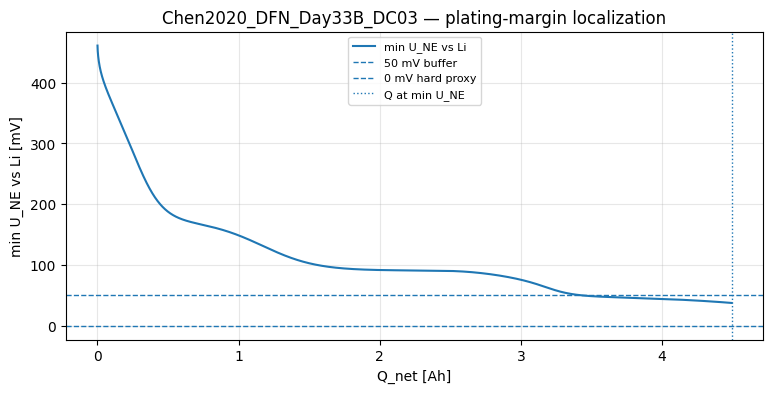

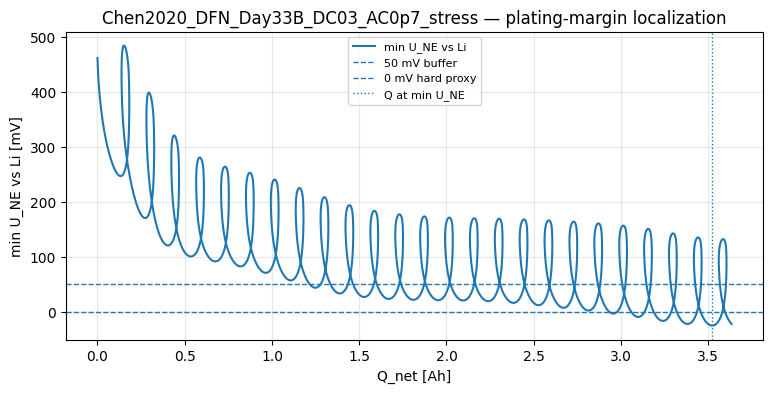

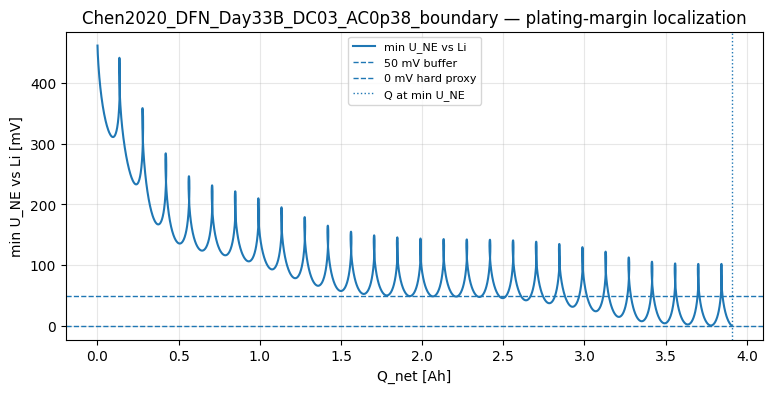

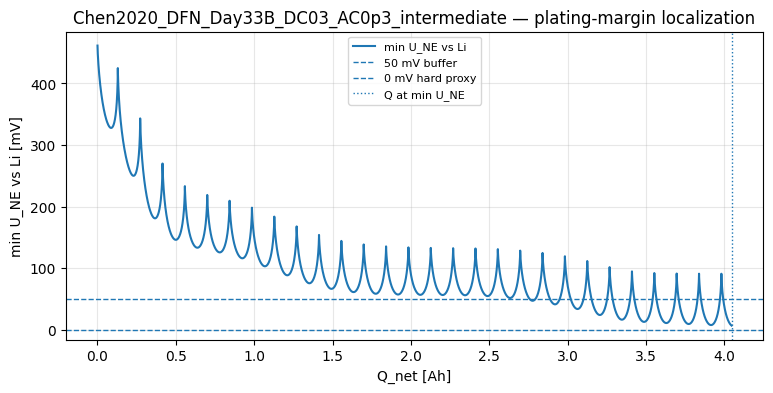

In [18]:
# Cell 9 — Plot U_NE margin and trigger location（绘制U_NE余量与风险触发位置）

for _, pr in day33b_protocol_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond]
    loc = risk_localization_df[risk_localization_df["condition"] == cond].iloc[0]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["Q_net_Ah"], ts["U_NE_min_mV"], label="min U_NE vs Li")
    ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
    ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")
    ax.axvline(loc["Q_at_min_U_NE_Ah"], linestyle=":", linewidth=1, label="Q at min U_NE")

    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("min U_NE vs Li [mV]")
    ax.set_title(f"{cond} — plating-margin localization")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

In [20]:
# Cell 10 — Compact Day33B risk-trigger map（Day33B紧凑风险触发图谱）

def classify_risk_mechanism(row):
    label = row["trigger_label_refined"]

    if row["margin_class"] == "safe_margin":
        return "safe_or_low_risk_reference"

    if "current_peak" in label and "high_Q_or_SOC" in label and "boundary_coupled" in label:
        return "peak_current_highSOC_boundary_coupled"

    if "high_Q_or_SOC" in label and "boundary_coupled" in label:
        return "highSOC_boundary_coupled"

    if "high_electrolyte_gradient" in label:
        return "transport_gradient_coupled"

    if "high_surface_heterogeneity" in label:
        return "surface_heterogeneity_coupled"

    return "mixed_or_unclear"

risk_localization_df["risk_mechanism_class"] = risk_localization_df.apply(
    classify_risk_mechanism,
    axis=1,
)

compact_trigger_df = risk_localization_df[
    [
        "condition",
        "case_role",
        "ac_c",
        "peak_c",
        "min_U_NE_mV",
        "margin_class",
        "Q_frac_of_DC_end_at_min_U_NE",
        "phase_norm_at_min_U_NE",
        "I_charge_at_min_U_NE_A",
        "V_terminal_at_min_U_NE_V",
        "distance_to_4p2V_at_min_U_NE_mV",
        "c_e_range_vs_DC_at_min",
        "surface_range_vs_DC_at_min",
        "eta_n_at_min_U_NE_V",
        "trigger_label_refined",
        "risk_mechanism_class",
    ]
].copy()

out = DATA_DIR / "day33b_compact_risk_trigger_map.csv"
compact_trigger_df.to_csv(out, index=False)

print("[OK] saved compact risk trigger map:", out)
display(compact_trigger_df)

[OK] saved compact risk trigger map: /Users/louislu/pybamm-dcac-superimposed/data/day33b_compact_risk_trigger_map.csv


,condition,case_role,ac_c,peak_c,min_U_NE_mV,margin_class,Q_frac_of_DC_end_at_min_U_NE,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_vs_DC_at_min,surface_range_vs_DC_at_min,eta_n_at_min_U_NE_V,trigger_label_refined,risk_mechanism_class
0,Chen2020_DFN_Day33B_DC03,dc_reference,0.00,0.30,37.280562,near_boundary,1.000000,NaN,1.500000,4.200000,0.000000e+00,1.000000,1.000000,-0.045310,dc_reference+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,highSOC_boundary_coupled
1,Chen2020_DFN_Day33B_DC03_AC0p7_stress,stress_case,0.70,1.00,-25.298691,risk_flag,0.784278,0.275995,4.953419,4.194624,5.376187e+00,2.714887,1.140533,-0.091412,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled,peak_current_highSOC_boundary_coupled
2,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,near_hard_margin_boundary,0.38,0.68,0.584036,near_boundary,0.869450,0.223159,3.373045,4.200000,-1.776357e-12,1.760244,1.086667,-0.073200,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
3,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,intermediate_reference,0.30,0.60,6.661005,near_boundary,0.900392,0.228216,2.985971,4.200000,-8.881784e-13,1.605718,1.073734,-0.068792,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled


## Day33C — Frequency sensitivity of plating-risk localization

Day33B showed that, at fixed `1.5τ_set`, the minimum negative-electrode margin occurs near high-Q / voltage-boundary-adjacent operation and is phase-locked to the AC charge-current peak.

Day33C tests whether this localization pattern is stable across representative normalized frequencies.

This is not a full frequency–amplitude optimization. It fixes the near-boundary amplitude:

```text
DC = 0.3C
AC = 0.38C
```

and scans:

```text
0.5τ_set
1.5τ_set
3.0τ_set
5.0τ_set
```

Main question:

> Does the minimum U_NE remain high-Q / boundary-coupled / charge-peak-coupled across frequencies, or does the trigger shift with forcing timescale?

The output is a frequency-sensitivity trigger map, not a fastest-protocol ranking.

In [22]:
# Cell 11 — Define Day33C frequency-sensitivity protocols（定义Day33C频率敏感性协议）

DAY33C_AC_C = 0.38
DAY33C_TAU_FACTORS = [0.5, 1.5, 3.0, 5.0]

def tau_label(tau_factor):
    return str(tau_factor).replace(".", "p") + "tauSet"

day33c_rows = []

# DC reference row: frequency-independent baseline.
day33c_rows.append({
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "condition": "Chen2020_DFN_Day33C_DC03",
    "protocol_type": "DC",
    "case_role": "dc_reference",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "peak_c": DC_C,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_set": np.nan,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
})

for tau_factor in DAY33C_TAU_FACTORS:
    f_hz = 1.0 / (2.0 * np.pi * tau_factor * TAU_REF_SET_S)
    period_s = 1.0 / f_hz
    day33c_rows.append({
        "parameter_set": PRIMARY_PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "condition": f"Chen2020_DFN_Day33C_DC03_AC0p38_{tau_label(tau_factor)}",
        "protocol_type": "DCAC",
        "case_role": f"AC0p38_{tau_label(tau_factor)}",
        "dc_c": DC_C,
        "ac_c": DAY33C_AC_C,
        "peak_c": DC_C + DAY33C_AC_C,
        "frequency_mode": FREQUENCY_MODE,
        "tau_factor_set": tau_factor,
        "tau_ref_set_s": TAU_REF_SET_S,
        "f_Hz": f_hz,
        "period_s": period_s,
        "omega_tau_set": 1.0 / tau_factor,
    })

day33c_protocol_df = pd.DataFrame(day33c_rows)

out = DATA_DIR / "day33c_frequency_sensitivity_protocol_table.csv"
day33c_protocol_df.to_csv(out, index=False)

print("[OK] saved Day33C protocol table:", out)
display(day33c_protocol_df)

[OK] saved Day33C protocol table: /Users/louislu/pybamm-dcac-superimposed/data/day33c_frequency_sensitivity_protocol_table.csv


,parameter_set,model_type,condition,protocol_type,case_role,dc_c,ac_c,peak_c,frequency_mode,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set
0,Chen2020,DFN,Chen2020_DFN_Day33C_DC03,DC,dc_reference,0.3,0.00,0.30,set_rebased,NaN,36.316532,NaN,NaN,NaN
1,Chen2020,DFN,Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet,DCAC,AC0p38_0p5tauSet,0.3,0.38,0.68,set_rebased,0.5,36.316532,0.008765,114.091751,2.000000
2,Chen2020,DFN,Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet,DCAC,AC0p38_1p5tauSet,0.3,0.38,0.68,set_rebased,1.5,36.316532,0.002922,342.275253,0.666667
3,Chen2020,DFN,Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet,DCAC,AC0p38_3p0tauSet,0.3,0.38,0.68,set_rebased,3.0,36.316532,0.001461,684.550505,0.333333
4,Chen2020,DFN,Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet,DCAC,AC0p38_5p0tauSet,0.3,0.38,0.68,set_rebased,5.0,36.316532,0.000876,1140.917509,0.200000


In [23]:
# Cell 12 — Run Day33C frequency-sensitivity simulations（运行Day33C频率敏感性仿真）

day33c_solutions = {}
day33c_run_rows = []

for _, row in day33c_protocol_df.iterrows():
    cond = row["condition"]

    # Reuse Day33B DC reference if available.
    if row["protocol_type"] == "DC" and "Chen2020_DFN_Day33B_DC03" in solutions:
        print(f"[REUSE] {cond} <- Chen2020_DFN_Day33B_DC03")
        day33c_solutions[cond] = solutions["Chen2020_DFN_Day33B_DC03"]
        ts_i = day33c_solutions[cond]["ts"]
        sol_i = day33c_solutions[cond]["sol"]
        day33c_run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok_reused",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "error": "",
        })
        continue

    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, meta_i = run_day33b_simulation(row.to_dict())

        day33c_solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "meta": meta_i,
            "protocol": row.to_dict(),
        }

        day33c_run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        day33c_run_rows.append({
            "condition": cond,
            "case_role": row["case_role"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "dc_c": row["dc_c"],
            "ac_c": row["ac_c"],
            "peak_c": row["peak_c"],
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

day33c_run_summary_df = pd.DataFrame(day33c_run_rows)

out = DATA_DIR / "day33c_run_summary.csv"
day33c_run_summary_df.to_csv(out, index=False)

print("[OK] saved Day33C run summary:", out)
display(day33c_run_summary_df)

[REUSE] Chen2020_DFN_Day33C_DC03 <- Chen2020_DFN_Day33B_DC03

[RUN] Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet
[OK] Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet
[OK] Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet
[OK] Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet
[OK] Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet | termination: event: Maximum voltage [V]
[OK] saved Day33C run summary: /Users/louislu/pybamm-dcac-superimposed/data/day33c_run_summary.csv


,condition,case_role,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,dc_c,ac_c,peak_c,tau_factor_set,f_Hz,error
0,Chen2020_DFN_Day33C_DC03,dc_reference,ok_reused,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.5,0.3,0.00,0.30,NaN,NaN,
1,Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet,AC0p38_0p5tauSet,ok,event: Maximum voltage [V],9609.815332,160.163589,4.012136,4.2,-0.400000,3.4,0.3,0.38,0.68,0.5,0.008765,
2,Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet,AC0p38_1p5tauSet,ok,event: Maximum voltage [V],9317.813665,155.296894,3.906333,4.2,-0.400000,3.4,0.3,0.38,0.68,1.5,0.002922,
3,Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet,AC0p38_3p0tauSet,ok,event: Maximum voltage [V],9067.798143,151.129969,3.834432,4.2,-0.399999,3.4,0.3,0.38,0.68,3.0,0.001461,
4,Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet,AC0p38_5p0tauSet,ok,event: Maximum voltage [V],9318.661077,155.311018,3.931228,4.2,-0.400000,3.4,0.3,0.38,0.68,5.0,0.000876,


In [24]:
# Cell 13 — Extract Day33C state timeseries（提取Day33C状态时间序列）

day33c_state_ts_map = {}
day33c_extract_rows = []

for cond, obj in day33c_solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_day33b_state_timeseries(obj)
    day33c_state_ts_map[cond] = ts

    day33c_extract_rows.append({
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "status": "ok",
    })

day33c_extract_audit_df = pd.DataFrame(day33c_extract_rows)

out = DATA_DIR / "day33c_state_extraction_audit.csv"
day33c_extract_audit_df.to_csv(out, index=False)

print("[OK] saved Day33C extraction audit:", out)
display(day33c_extract_audit_df)

[EXTRACT] Chen2020_DFN_Day33C_DC03
[EXTRACT] Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet
[EXTRACT] Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet
[EXTRACT] Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet
[EXTRACT] Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet
[OK] saved Day33C extraction audit: /Users/louislu/pybamm-dcac-superimposed/data/day33c_state_extraction_audit.csv


,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,status
0,Chen2020_DFN_Day33C_DC03,12159,37.280562,0.219837,0.000000,377.868423,0.116717,ok
1,Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet,18334,3.541303,0.125341,0.000000,602.779671,0.121326,ok
2,Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet,14511,0.584036,0.145062,0.000000,748.029412,0.133276,ok
3,Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet,12602,-1.223625,0.153230,0.001666,782.192534,0.136783,ok
4,Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet,11865,1.731924,0.168563,0.000000,793.176697,0.138090,ok


In [25]:
# Cell 14 — Localize Day33C minimum U_NE and triggers（定位Day33C最小U_NE与触发机制）

def day33c_refined_trigger_label(row):
    labels = []

    is_dcac = row["protocol_type"] == "DCAC"

    if row["protocol_type"] == "DC":
        labels.append("dc_reference")

    if is_dcac:
        if row["I_charge_at_min_U_NE_A"] >= 0.9 * row["I_charge_peak_A"]:
            labels.append("current_peak")

        if pd.notna(row["phase_norm_at_min_U_NE"]):
            if 0.15 <= row["phase_norm_at_min_U_NE"] <= 0.35:
                labels.append("charge_peak_phase")

    if row["Q_frac_of_DC_end_at_min_U_NE"] >= 0.75:
        labels.append("high_Q_or_SOC")

    if row["distance_to_4p2V_at_min_U_NE_mV"] <= 50:
        labels.append("boundary_coupled")

    if row["c_e_range_at_min_U_NE_molm3"] >= row["c_e_range_p90_molm3"]:
        labels.append("high_electrolyte_gradient")

    if row["neg_surface_sto_range_at_min_U_NE"] >= row["neg_surface_sto_range_p90"]:
        labels.append("high_surface_heterogeneity")

    if len(labels) == 0:
        labels.append("unclear")

    return "+".join(labels)


def classify_risk_mechanism(row):
    label = row["trigger_label"]

    if row["margin_class"] == "safe_margin":
        return "safe_or_low_risk_reference"

    if "current_peak" in label and "high_Q_or_SOC" in label and "boundary_coupled" in label:
        return "peak_current_highSOC_boundary_coupled"

    if "high_Q_or_SOC" in label and "boundary_coupled" in label:
        return "highSOC_boundary_coupled"

    if "high_electrolyte_gradient" in label:
        return "transport_gradient_coupled"

    if "high_surface_heterogeneity" in label:
        return "surface_heterogeneity_coupled"

    return "mixed_or_unclear"


dc_cond_c = "Chen2020_DFN_Day33C_DC03"
dc_Q_end_Ah_c = float(day33c_state_ts_map[dc_cond_c]["Q_net_Ah"].max())
dc_ref_placeholder = None

loc_rows = []

for _, pr in day33c_protocol_df.iterrows():
    cond = pr["condition"]
    ts = day33c_state_ts_map[cond].copy()

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    f_hz = None if pd.isna(pr["f_Hz"]) else float(pr["f_Hz"])
    phase_norm = compute_phase_norm(float(r["t_s"]), f_hz)

    i_peak_A = float(day33c_solutions[cond]["meta"]["i_dc_A"] + day33c_solutions[cond]["meta"]["i_ac_A"])

    c_e_range_p90 = float(np.nanpercentile(ts["c_e_range_molm3"], 90))
    sto_range_p90 = float(np.nanpercentile(ts["neg_surface_sto_range"], 90))

    row = {
        "condition": cond,
        "protocol_type": pr["protocol_type"],
        "case_role": pr["case_role"],
        "dc_c": pr["dc_c"],
        "ac_c": pr["ac_c"],
        "peak_c": pr["peak_c"],
        "tau_factor_set": pr["tau_factor_set"],
        "f_Hz": pr["f_Hz"],
        "period_s": pr["period_s"],
        "omega_tau_set": pr["omega_tau_set"],
        "t_at_min_U_NE_s": float(r["t_s"]),
        "t_at_min_U_NE_min": float(r["t_s"] / 60.0),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "Q_frac_of_DC_end_at_min_U_NE": float(r["Q_net_Ah"] / dc_Q_end_Ah_c),
        "phase_norm_at_min_U_NE": phase_norm,
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_A": i_peak_A,
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "distance_to_4p2V_at_min_U_NE_mV": float((4.2 - r["V_terminal_V"]) * 1000.0),
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "U_NE_separator_at_min_mV": float(r["U_NE_separator_V"] * 1000.0),
        "U_NE_xavg_at_min_mV": float(r["U_NE_xavg_V"] * 1000.0),
        "margin_class": classify_margin(float(r["U_NE_min_V"])),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "c_e_min_at_min_U_NE_molm3": float(r["c_e_min_molm3"]),
        "c_e_max_at_min_U_NE_molm3": float(r["c_e_max_molm3"]),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "c_e_range_p90_molm3": c_e_range_p90,
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]) if np.isfinite(r["eta_n_V"]) else np.nan,
        "eta_p_at_min_U_NE_V": float(r["eta_p_V"]) if np.isfinite(r["eta_p_V"]) else np.nan,
        "neg_surface_sto_xavg_at_min_U_NE": float(r["neg_surface_sto_xavg"]) if np.isfinite(r["neg_surface_sto_xavg"]) else np.nan,
        "neg_surface_sto_max_at_min_U_NE": float(r["neg_surface_sto_max"]) if np.isfinite(r["neg_surface_sto_max"]) else np.nan,
        "neg_surface_sto_min_at_min_U_NE": float(r["neg_surface_sto_min"]) if np.isfinite(r["neg_surface_sto_min"]) else np.nan,
        "neg_surface_sto_range_at_min_U_NE": float(r["neg_surface_sto_range"]) if np.isfinite(r["neg_surface_sto_range"]) else np.nan,
        "neg_surface_sto_range_p90": sto_range_p90,
    }

    row["trigger_label"] = day33c_refined_trigger_label(row)
    row["risk_mechanism_class"] = classify_risk_mechanism(row)

    loc_rows.append(row)

day33c_risk_localization_df = pd.DataFrame(loc_rows)

# Add normalized state variables relative to DC at min.
dc_row_c = day33c_risk_localization_df[
    day33c_risk_localization_df["condition"] == dc_cond_c
].iloc[0]

day33c_risk_localization_df["c_e_range_vs_DC_at_min"] = (
    day33c_risk_localization_df["c_e_range_at_min_U_NE_molm3"]
    / dc_row_c["c_e_range_at_min_U_NE_molm3"]
)

day33c_risk_localization_df["surface_range_vs_DC_at_min"] = (
    day33c_risk_localization_df["neg_surface_sto_range_at_min_U_NE"]
    / dc_row_c["neg_surface_sto_range_at_min_U_NE"]
)

out = DATA_DIR / "day33c_frequency_sensitivity_risk_localization.csv"
day33c_risk_localization_df.to_csv(out, index=False)

print("[OK] saved Day33C frequency-sensitivity risk localization:", out)

cols = [
    "condition",
    "case_role",
    "tau_factor_set",
    "f_Hz",
    "period_s",
    "min_U_NE_mV",
    "margin_class",
    "Q_frac_of_DC_end_at_min_U_NE",
    "phase_norm_at_min_U_NE",
    "I_charge_at_min_U_NE_A",
    "I_charge_peak_A",
    "V_terminal_at_min_U_NE_V",
    "distance_to_4p2V_at_min_U_NE_mV",
    "c_e_range_at_min_U_NE_molm3",
    "c_e_range_vs_DC_at_min",
    "neg_surface_sto_range_at_min_U_NE",
    "surface_range_vs_DC_at_min",
    "eta_n_at_min_U_NE_V",
    "trigger_label",
    "risk_mechanism_class",
]

display(day33c_risk_localization_df[cols])

[OK] saved Day33C frequency-sensitivity risk localization: /Users/louislu/pybamm-dcac-superimposed/data/day33c_frequency_sensitivity_risk_localization.csv


,condition,case_role,tau_factor_set,f_Hz,period_s,min_U_NE_mV,margin_class,Q_frac_of_DC_end_at_min_U_NE,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,I_charge_peak_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_at_min_U_NE_molm3,c_e_range_vs_DC_at_min,neg_surface_sto_range_at_min_U_NE,surface_range_vs_DC_at_min,eta_n_at_min_U_NE_V,trigger_label,risk_mechanism_class
0,Chen2020_DFN_Day33C_DC03,dc_reference,NaN,NaN,NaN,37.280562,near_boundary,1.000000,NaN,1.500000,1.5,4.200000,0.000000e+00,354.118549,1.000000,0.116717,1.000000,-0.045310,dc_reference+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,highSOC_boundary_coupled
1,Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet,AC0p38_0p5tauSet,0.5,0.008765,114.091751,3.541303,near_boundary,0.883546,0.275961,3.374779,3.4,4.199148,8.523046e-01,480.454245,1.356761,0.117722,1.008613,-0.072441,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
2,Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet,AC0p38_1p5tauSet,1.5,0.002922,342.275253,0.584036,near_boundary,0.869450,0.223159,3.373045,3.4,4.200000,-1.776357e-12,623.335049,1.760244,0.126832,1.086667,-0.073200,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
3,Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet,AC0p38_3p0tauSet,3.0,0.001461,684.550505,-1.223625,risk_flag,0.853447,0.246354,3.399501,3.4,4.200000,-3.375078e-11,714.541263,2.017802,0.126933,1.087530,-0.073703,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
4,Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet,AC0p38_5p0tauSet,5.0,0.000876,1140.917509,1.731924,near_boundary,0.791973,0.264751,3.391846,3.4,4.162197,3.780260e+01,741.536786,2.094035,0.105339,0.902523,-0.071293,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_electrolyte_gradient,peak_current_highSOC_boundary_coupled


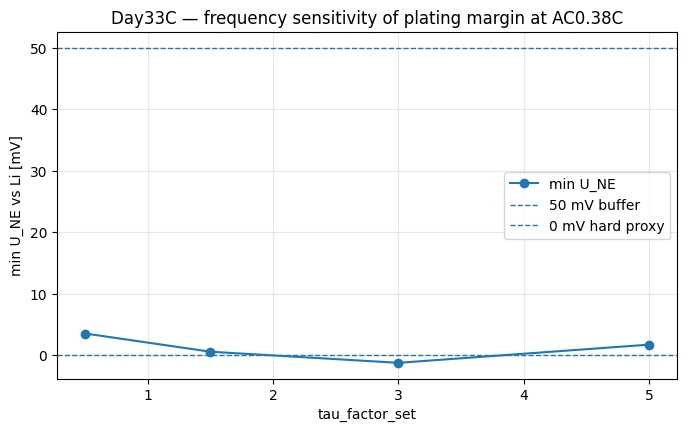

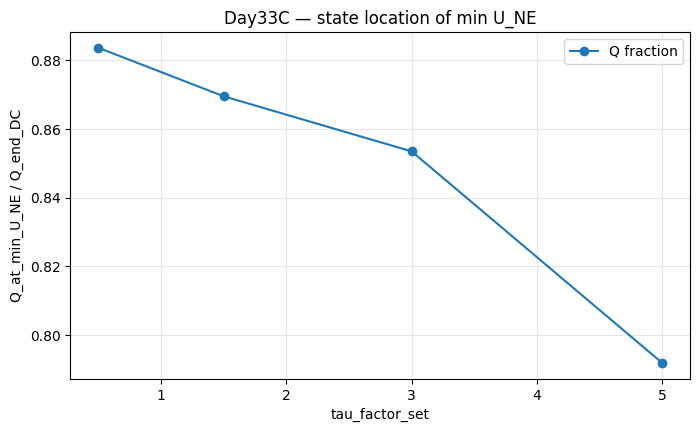

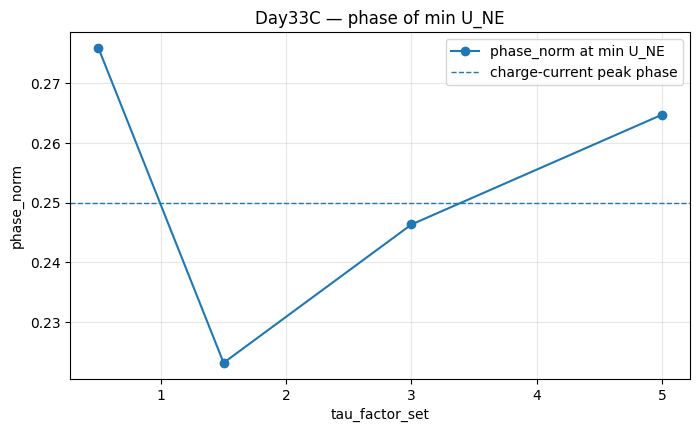

In [26]:
# Cell 15 — Plot Day33C frequency sensitivity（绘制Day33C频率敏感性）

plot_df = day33c_risk_localization_df[
    day33c_risk_localization_df["protocol_type"] == "DCAC"
].sort_values("tau_factor_set")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot_df["tau_factor_set"], plot_df["min_U_NE_mV"], marker="o", label="min U_NE")
ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")
ax.set_xlabel("tau_factor_set")
ax.set_ylabel("min U_NE vs Li [mV]")
ax.set_title("Day33C — frequency sensitivity of plating margin at AC0.38C")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot_df["tau_factor_set"], plot_df["Q_frac_of_DC_end_at_min_U_NE"], marker="o", label="Q fraction")
ax.set_xlabel("tau_factor_set")
ax.set_ylabel("Q_at_min_U_NE / Q_end_DC")
ax.set_title("Day33C — state location of min U_NE")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot_df["tau_factor_set"], plot_df["phase_norm_at_min_U_NE"], marker="o", label="phase_norm at min U_NE")
ax.axhline(0.25, linestyle="--", linewidth=1, label="charge-current peak phase")
ax.set_xlabel("tau_factor_set")
ax.set_ylabel("phase_norm")
ax.set_title("Day33C — phase of min U_NE")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [27]:
# Cell 16 — Day33 final synthesis table（Day33最终综合表）

day33b_compact = compact_trigger_df.copy()
day33b_compact["section"] = "Day33B_fixed_1p5tau"

day33c_compact = day33c_risk_localization_df[
    [
        "condition",
        "case_role",
        "ac_c",
        "peak_c",
        "min_U_NE_mV",
        "margin_class",
        "Q_frac_of_DC_end_at_min_U_NE",
        "phase_norm_at_min_U_NE",
        "I_charge_at_min_U_NE_A",
        "V_terminal_at_min_U_NE_V",
        "distance_to_4p2V_at_min_U_NE_mV",
        "c_e_range_vs_DC_at_min",
        "surface_range_vs_DC_at_min",
        "eta_n_at_min_U_NE_V",
        "trigger_label",
        "risk_mechanism_class",
    ]
].copy()

day33c_compact = day33c_compact.rename(columns={
    "trigger_label": "trigger_label_refined"
})
day33c_compact["section"] = "Day33C_frequency_sensitivity"

day33_final_synthesis_df = pd.concat(
    [day33b_compact, day33c_compact],
    ignore_index=True,
    sort=False,
)

out = DATA_DIR / "day33_final_risk_localization_synthesis.csv"
day33_final_synthesis_df.to_csv(out, index=False)

print("[OK] saved Day33 final synthesis:", out)

display(
    day33_final_synthesis_df[
        [
            "section",
            "condition",
            "case_role",
            "ac_c",
            "peak_c",
            "min_U_NE_mV",
            "margin_class",
            "Q_frac_of_DC_end_at_min_U_NE",
            "phase_norm_at_min_U_NE",
            "I_charge_at_min_U_NE_A",
            "V_terminal_at_min_U_NE_V",
            "distance_to_4p2V_at_min_U_NE_mV",
            "c_e_range_vs_DC_at_min",
            "surface_range_vs_DC_at_min",
            "trigger_label_refined",
            "risk_mechanism_class",
        ]
    ]
)

[OK] saved Day33 final synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day33_final_risk_localization_synthesis.csv


,section,condition,case_role,ac_c,peak_c,min_U_NE_mV,margin_class,Q_frac_of_DC_end_at_min_U_NE,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_vs_DC_at_min,surface_range_vs_DC_at_min,trigger_label_refined,risk_mechanism_class
0,Day33B_fixed_1p5tau,Chen2020_DFN_Day33B_DC03,dc_reference,0.00,0.30,37.280562,near_boundary,1.000000,NaN,1.500000,4.200000,0.000000e+00,1.000000,1.000000,dc_reference+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,highSOC_boundary_coupled
1,Day33B_fixed_1p5tau,Chen2020_DFN_Day33B_DC03_AC0p7_stress,stress_case,0.70,1.00,-25.298691,risk_flag,0.784278,0.275995,4.953419,4.194624,5.376187e+00,2.714887,1.140533,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled,peak_current_highSOC_boundary_coupled
2,Day33B_fixed_1p5tau,Chen2020_DFN_Day33B_DC03_AC0p38_boundary,near_hard_margin_boundary,0.38,0.68,0.584036,near_boundary,0.869450,0.223159,3.373045,4.200000,-1.776357e-12,1.760244,1.086667,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
3,Day33B_fixed_1p5tau,Chen2020_DFN_Day33B_DC03_AC0p3_intermediate,intermediate_reference,0.30,0.60,6.661005,near_boundary,0.900392,0.228216,2.985971,4.200000,-8.881784e-13,1.605718,1.073734,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
4,Day33C_frequency_sensitivity,Chen2020_DFN_Day33C_DC03,dc_reference,0.00,0.30,37.280562,near_boundary,1.000000,NaN,1.500000,4.200000,0.000000e+00,1.000000,1.000000,dc_reference+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,highSOC_boundary_coupled
5,Day33C_frequency_sensitivity,Chen2020_DFN_Day33C_DC03_AC0p38_0p5tauSet,AC0p38_0p5tauSet,0.38,0.68,3.541303,near_boundary,0.883546,0.275961,3.374779,4.199148,8.523046e-01,1.356761,1.008613,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
6,Day33C_frequency_sensitivity,Chen2020_DFN_Day33C_DC03_AC0p38_1p5tauSet,AC0p38_1p5tauSet,0.38,0.68,0.584036,near_boundary,0.869450,0.223159,3.373045,4.200000,-1.776357e-12,1.760244,1.086667,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
7,Day33C_frequency_sensitivity,Chen2020_DFN_Day33C_DC03_AC0p38_3p0tauSet,AC0p38_3p0tauSet,0.38,0.68,-1.223625,risk_flag,0.853447,0.246354,3.399501,4.200000,-3.375078e-11,2.017802,1.087530,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_surface_heterogeneity,peak_current_highSOC_boundary_coupled
8,Day33C_frequency_sensitivity,Chen2020_DFN_Day33C_DC03_AC0p38_5p0tauSet,AC0p38_5p0tauSet,0.38,0.68,1.731924,near_boundary,0.791973,0.264751,3.391846,4.162197,3.780260e+01,2.094035,0.902523,current_peak+charge_peak_phase+high_Q_or_SOC+boundary_coupled+high_electrolyte_gradient,peak_current_highSOC_boundary_coupled


## Final closure — Notebook 33

Notebook 33 moved the DC–AC analysis from gain–margin classification to plating-risk localization.

Day33A froze the variable lineage and registry. The primary plating-margin proxy is `Negative electrode surface potential difference [V]`, reduced by spatial minimum over the negative electrode. Negative-electrode OCP is explicitly not used as a primary plating-risk criterion.

Day33B localized the minimum U_NE under the Chen2020 / DFN mainline protocol set. At fixed `1.5τ_set`, the minimum U_NE occurs in the high-Q / voltage-boundary-adjacent region. For DC–AC cases, the minimum is also phase-locked to the charge-current peak. The stress case `0.3C + 0.7C` crosses the 0 mV hard-margin proxy, while `0.3C + 0.38C` and `0.3C + 0.3C` remain near-boundary.

Day33C tested frequency sensitivity at the near-boundary amplitude `0.3C + 0.38C`. Across `0.5τ_set`, `1.5τ_set`, `3τ_set`, and `5τ_set`, the dominant trigger structure remains stable: current peak + charge peak phase + high-Q/SOC + voltage-boundary coupling. Frequency changes the severity and state location of the minimum U_NE, but it does not change the dominant trigger mechanism. The `3τ_set` case crosses the 0 mV proxy in this run, while the other representative frequencies remain near-boundary.

Correct conclusion wording: DC–AC plating-margin risk is localized, not trajectory-uniform. In the tested Chen2020 / DFN setting, the dominant risk trigger is peak-current forcing applied near high-Q / voltage-boundary-adjacent operation. Electrolyte-gradient and surface-heterogeneity variables provide explanatory background states, especially at longer periods, but the immediate risk minimum is primarily peak-current/high-Q/boundary coupled.

Interpretation boundary: This notebook does not prove experimentally confirmed lithium plating. It audits a virtual three-electrode thermodynamic proxy under isothermal PyBaMM DFN assumptions. Thermal and aging admissibility remain deferred.

Next step: Day34 should use this risk-trigger map to design state-aware DC–AC waveform scheduling, including high-SOC AC derating or shutdown, peak-current clipping, and U_NE-margin-aware control.

### Microstate-context boundary

Notebook 33 does not repeat the full equal-Q microstate-response audit from Notebook 30. Instead, it uses selected microstate variables as explanatory context at the localized minimum-U_NE point.

The extracted microstate context includes electrolyte concentration range, negative-surface stoichiometry range, and negative-electrode reaction overpotential at the time of minimum U_NE. These variables help interpret whether the risk point is accompanied by transport-gradient amplification, surface-state heterogeneity, or stronger kinetic polarization.

In the current Chen2020 / DFN localization map, the dominant trigger structure is peak-current + high-Q/SOC + voltage-boundary coupling. Electrolyte-gradient and surface-heterogeneity variables are important background states, especially under DC–AC, but they are not used here as standalone admissibility criteria. The hard admissibility criterion remains the negative-electrode potential proxy U_NE vs Li/Li+.